# We will create all the official models for predictions here

In [ ]:
# -- import libraries
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, RandomizedSearchCV
from scipy.stats import pointbiserialr
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from matplotlib.patches import Patch
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
matches_w_stats = pd.read_csv('matches_detailed_with_history.csv')
teams = pd.read_csv('teams.xls')
duals = pd.read_csv('dual_meets.xls')
wrestlers = pd.read_csv('wrestlers_updated.csv')
matches_w_stats['home_win'] = matches_w_stats['home_win'].astype('int')

In [ ]:
# -- Filter out entries at the begining of the season
# ============================================
# FILTER OUT EARLY SEASON MATCHES WITH ALL ZERO STATS
# ============================================

print("="*80)
print("FILTERING OUT EARLY SEASON MATCHES")
print("="*80)

# List of columns that should have non-zero values for meaningful matches
stat_cols = [
    'home_matches_wrestled', 'home_win_rate', 'home_bonus_rate', 'home_pin_count',
    'home_avg_point_diff', 'home_avg_points_scored', 'home_std_point_diff',
    'away_matches_wrestled', 'away_win_rate', 'away_bonus_rate', 'away_pin_count',
    'away_avg_point_diff', 'away_avg_points_scored', 'away_std_point_diff'
]

# Also include historical matchup features
history_cols = ['wrestled_before', 'home_point_diff_rematches', 'home_pinned_away']
all_filter_cols = stat_cols + history_cols

# Original shape
original_shape = matches_w_stats.shape
print(f"Original dataset: {original_shape[0]} matches, {original_shape[1]} columns")

# Create a filter for matches where ANY of these columns are non-zero
# This means at least one wrestler has some history
filter_mask = (matches_w_stats[stat_cols].sum(axis=1) > 0) | (matches_w_stats[history_cols].sum(axis=1) > 0)

# Alternative: Stricter filter - both wrestlers must have some history
# filter_mask = (matches_w_stats['home_matches_wrestled'] > 0) & (matches_w_stats['away_matches_wrestled'] > 0)

# Filter the dataframe
matches_w_stats_filtered = matches_w_stats[filter_mask].copy().reset_index(drop=True)

# New shape
new_shape = matches_w_stats_filtered.shape
print(f"Filtered dataset: {new_shape[0]} matches, {new_shape[1]} columns")
print(f"Removed {original_shape[0] - new_shape[0]} matches with all zero stats")
print(f"Kept {new_shape[0]/original_shape[0]*100:.1f}% of original matches")

# Verify first few rows now have non-zero values
print("\n📊 First 5 rows after filtering:")
print(matches_w_stats_filtered[['dual_id', 'home_name', 'away_name', 'home_matches_wrestled', 'away_matches_wrestled']].head(10))

# Now use matches_w_stats_filtered for all subsequent preprocessing and modeling
matches_w_stats = matches_w_stats_filtered

FILTERING OUT EARLY SEASON MATCHES
Original dataset: 5632 matches, 41 columns
Filtered dataset: 5128 matches, 41 columns
Removed 504 matches with all zero stats
Kept 91.1% of original matches

📊 First 5 rows after filtering:
   dual_id       home_name         away_name  home_matches_wrestled  \
0      277   Eric Alderfer   Nate Blanchette                      1   
1      276    Hunter Catka       Rocky Files                      1   
2      279      Chris Neal      James Rowley                      0   
3      277  Dustin Elliott      Andrew Clark                      1   
4      277     Gavin Mundy     Dylan Shawver                      1   
5      276       PJ Casale  Joshua McCutchen                      0   
6      276    Andrew Clark        Drew Pepin                      1   
7      276       Ryan Ford  Nathan McCartney                      1   
8      276   Anthony White   Joseph Giordano                      1   
9      276   Joey Olivieri  Dominic DiTullio                     

POINT-BISERIAL CORRELATIONS WITH HOME_WIN

Top 10 correlations with home_win:
                  feature  correlation        p_value significant
0               home_rank    -0.471203  8.100723e-282         Yes
1               away_rank     0.424199  3.967576e-223         Yes
2           home_win_rate     0.343842  2.877688e-142         Yes
3     home_avg_point_diff     0.332215  2.250639e-132         Yes
4           away_win_rate    -0.308883  8.785248e-114         Yes
5     away_avg_point_diff    -0.302305  7.750812e-109         Yes
6  home_avg_points_scored     0.293116  3.850262e-102         Yes
7  away_avg_points_scored    -0.277947   1.279780e-91         Yes
8         home_bonus_rate     0.265675   1.396546e-83         Yes
9          home_loss_rate    -0.263902   1.871365e-82         Yes


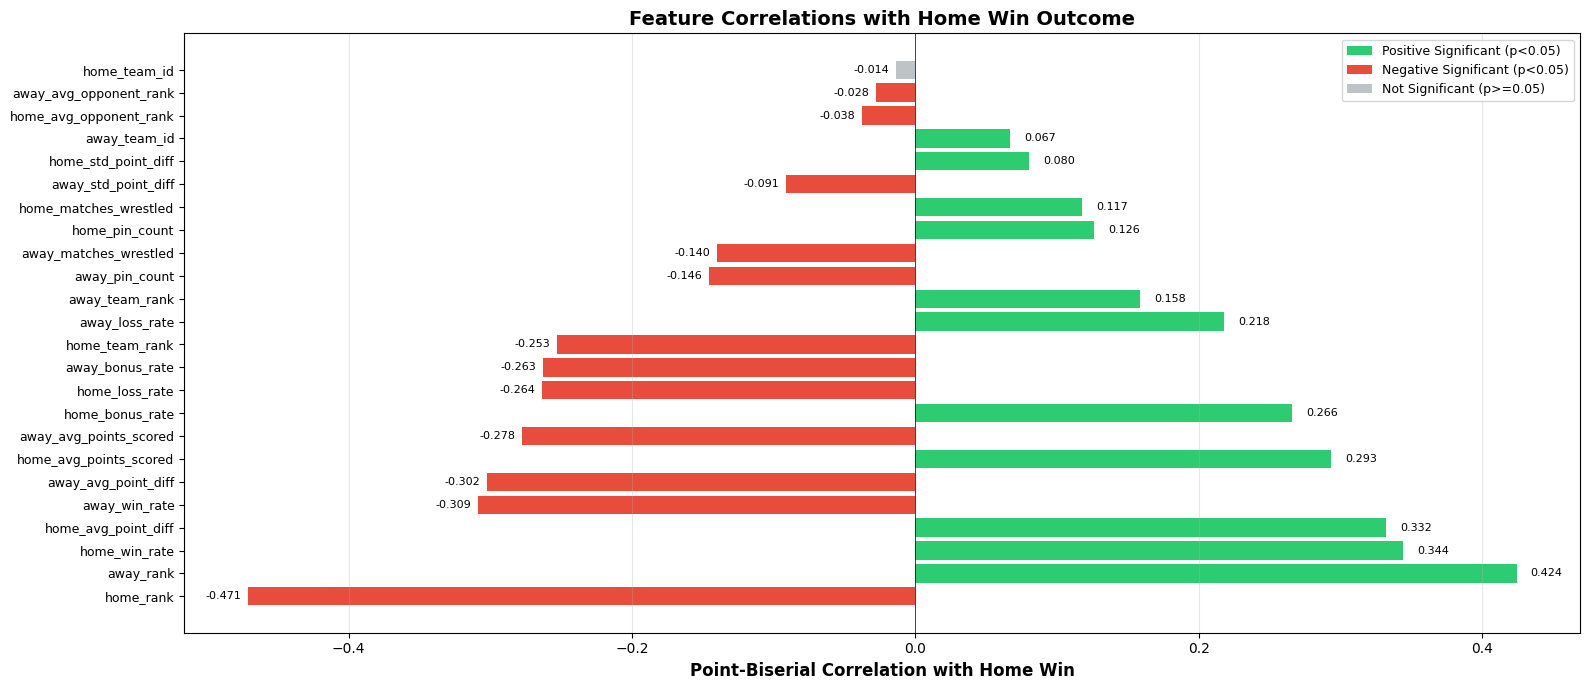


FULL CORRELATION HEATMAP


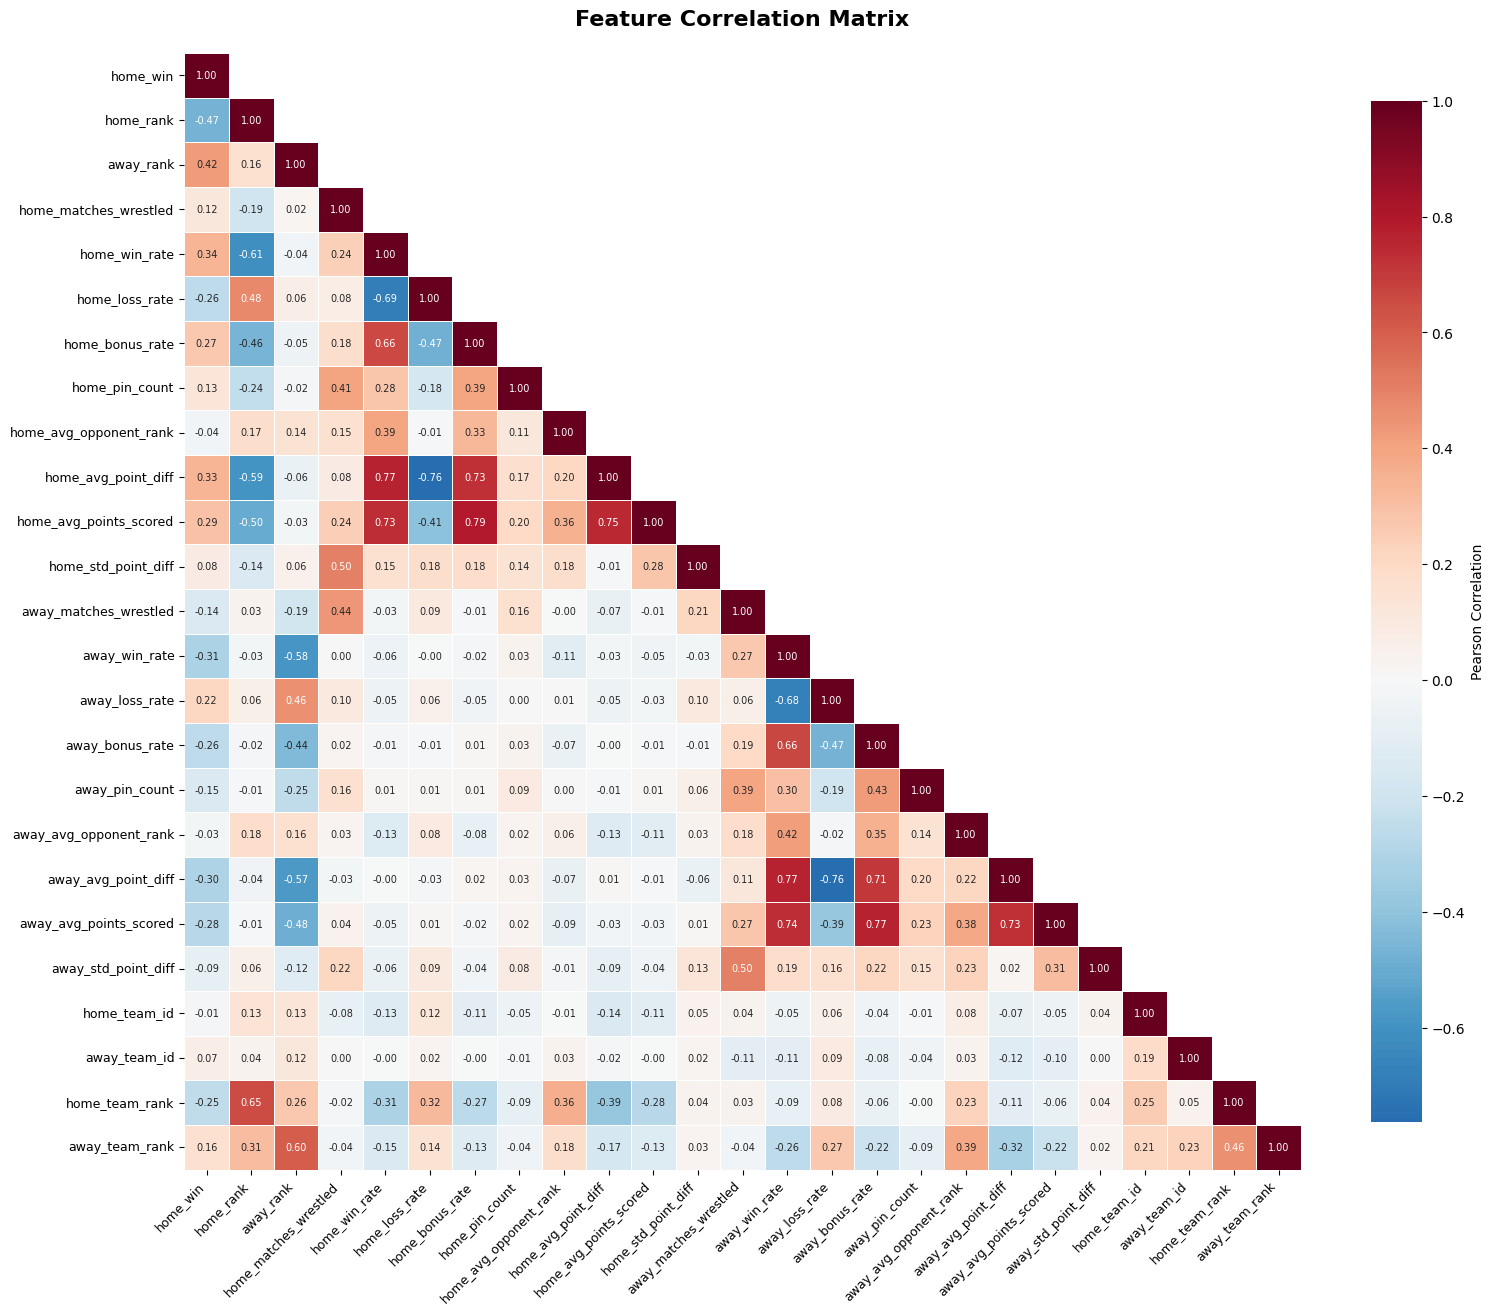


STRONG CORRELATIONS (|r| > 0.7)
           feature1               feature2  correlation
    home_bonus_rate home_avg_points_scored     0.789407
    away_bonus_rate away_avg_points_scored     0.772009
      home_win_rate    home_avg_point_diff     0.770651
      away_win_rate    away_avg_point_diff     0.767912
home_avg_point_diff home_avg_points_scored     0.746203
      away_win_rate away_avg_points_scored     0.735644
      home_win_rate home_avg_points_scored     0.733281
away_avg_point_diff away_avg_points_scored     0.730528
    home_bonus_rate    home_avg_point_diff     0.729887
    away_bonus_rate    away_avg_point_diff     0.707103
     away_loss_rate    away_avg_point_diff    -0.763025
     home_loss_rate    home_avg_point_diff    -0.763286

FEATURES RANKED BY CORRELATION WITH HOME_WIN
away_rank                 0.424199
home_win_rate             0.343842
home_avg_point_diff       0.332215
home_avg_points_scored    0.293116
home_bonus_rate           0.265675
away_loss_rate    

In [ ]:
# ============================================
# POINT-BISERIAL CORRELATIONS WITH HOME_WIN
# ============================================
num_subs = matches_w_stats[["home_win", "home_rank", "away_rank", 'home_matches_wrestled',
       'home_win_rate', 'home_loss_rate', 'home_bonus_rate', 'home_pin_count',
       'home_avg_opponent_rank', 'home_avg_point_diff',
       'home_avg_points_scored', 'home_std_point_diff',
       'away_matches_wrestled', 'away_win_rate', 'away_loss_rate',
       'away_bonus_rate', 'away_pin_count', 'away_avg_opponent_rank',
       'away_avg_point_diff', 'away_avg_points_scored', 'away_std_point_diff',
       'home_team_id', 'away_team_id', 'home_team_rank', 'away_team_rank']]
print("="*60)
print("POINT-BISERIAL CORRELATIONS WITH HOME_WIN")
print("="*60)

# Get features (excluding home_win)
feature_cols = [col for col in num_subs.columns if col != 'home_win']

# Calculate point-biserial correlations
correlations = []
p_values = []

for col in feature_cols:
    valid_data = num_subs[[col, 'home_win']].dropna()
    if len(valid_data) > 1:
        corr, p_value = pointbiserialr(valid_data['home_win'], valid_data[col])
        correlations.append(corr)
        p_values.append(p_value)
    else:
        correlations.append(np.nan)
        p_values.append(np.nan)

# Create results dataframe
corr_results = pd.DataFrame({
    'feature': feature_cols,
    'correlation': correlations,
    'p_value': p_values,
    'abs_correlation': [abs(c) if not pd.isna(c) else 0 for c in correlations],
    'significant': ['Yes' if p < 0.05 else 'No' if not pd.isna(p) else 'NaN' for p in p_values]
})

# Sort by absolute correlation
corr_results = corr_results.sort_values('abs_correlation', ascending=False).reset_index(drop=True)

print("\nTop 10 correlations with home_win:")
print(corr_results.head(10)[['feature', 'correlation', 'p_value', 'significant']].to_string())

# ============================================
# PLOT 1: POINT-BISERIAL CORRELATIONS BAR CHART
# ============================================

plt.figure(figsize=(16, 7))

# Color bars based on significance and direction
colors = []
for idx, row in corr_results.iterrows():
    if pd.isna(row['p_value']):
        colors.append('gray')
    elif row['p_value'] < 0.05:
        if row['correlation'] > 0:
            colors.append('#2ecc71')  # Green for positive significant
        else:
            colors.append('#e74c3c')  # Red for negative significant
    else:
        colors.append('#bdc3c7')  # Light gray for not significant

bars = plt.barh(range(len(corr_results)), corr_results['correlation'], color=colors)
plt.yticks(range(len(corr_results)), corr_results['feature'], fontsize=9)
plt.xlabel('Point-Biserial Correlation with Home Win', fontsize=12, fontweight='bold')
plt.title('Feature Correlations with Home Win Outcome', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, corr) in enumerate(zip(bars, corr_results['correlation'])):
    if not pd.isna(corr):
        x_pos = bar.get_width()
        if x_pos > 0:
            plt.text(x_pos + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{corr:.3f}', va='center', fontsize=8)
        else:
            plt.text(x_pos - 0.03, bar.get_y() + bar.get_height()/2,
                    f'{corr:.3f}', va='center', fontsize=8)

# Add legend
legend_elements = [
    Patch(facecolor='#2ecc71', label='Positive Significant (p<0.05)'),
    Patch(facecolor='#e74c3c', label='Negative Significant (p<0.05)'),
    Patch(facecolor='#bdc3c7', label='Not Significant (p>=0.05)'),
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('pointbiserial_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# PLOT 2: FULL CORRELATION HEATMAP
# ============================================

print("\n" + "="*60)
print("FULL CORRELATION HEATMAP")
print("="*60)

# Calculate correlation matrix
corr_matrix = num_subs.corr()

plt.figure(figsize=(16, 14))

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# Create heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"},
    annot_kws={"size": 7}
)

plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
#plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# HIGHLIGHT STRONG CORRELATIONS
# ============================================

print("\n" + "="*60)
print("STRONG CORRELATIONS (|r| > 0.7)")
print("="*60)

# Find pairs with strong correlation
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            strong_corr.append({
                'feature1': corr_matrix.columns[i],
                'feature2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

strong_corr_df = pd.DataFrame(strong_corr).sort_values('correlation', ascending=False)
if len(strong_corr_df) > 0:
    print(strong_corr_df.to_string(index=False))
else:
    print("No correlations above 0.7")

# ============================================
# CORRELATIONS WITH HOME_WIN (SORTED)
# ============================================

print("\n" + "="*60)
print("FEATURES RANKED BY CORRELATION WITH HOME_WIN")
print("="*60)

home_win_corr = corr_matrix['home_win'].drop('home_win').sort_values(ascending=False)
print(home_win_corr.to_string())

# BASELINE LOGISTIC REGRESSION MODEL

Point-biserial correlation: 0.4490222352998533
p-value: 5.707003910236577e-253


/tmp/ipykernel_140/553663289.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_logreg['win_rate_diff'] = matches_logreg['home_win_rate'] - matches_logreg['away_win_rate']


,home_win,win_rate_diff
0,1,1.000000
1,1,1.000000
2,0,0.000000
3,0,0.000000
4,0,0.000000
...,...,...
5123,0,0.125000
5124,1,-0.333333
5125,0,-0.375000
5126,0,-0.166667


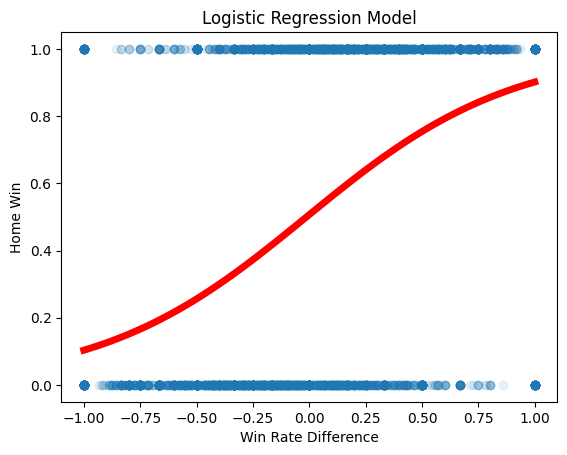

In [ ]:
# -- SOLE FEATURE IS DIFFERENCE IN RANK
matches_logreg = matches_w_stats[["home_win_rate", "away_win_rate", "home_win"]]
matches_logreg['win_rate_diff'] = matches_logreg['home_win_rate'] - matches_logreg['away_win_rate']
matches_logreg = matches_logreg.drop(columns=['home_win_rate', 'away_win_rate'])

r, p = pointbiserialr(matches_logreg["home_win"], matches_logreg["win_rate_diff"])
print("Point-biserial correlation:", r)
print("p-value:", p)

display(matches_logreg)


sns.regplot(x='win_rate_diff', y='home_win', data=matches_logreg, logistic=True, ci=None, scatter_kws={'alpha':0.1}, line_kws={'color': 'red', 'linewidth':5})
plt.xlabel('Win Rate Difference')
plt.ylabel('Home Win'); plt.title('Logistic Regression Model');
plt.show()


Train score: 0.7091092098641167
Validation score: 0.6975736568457539


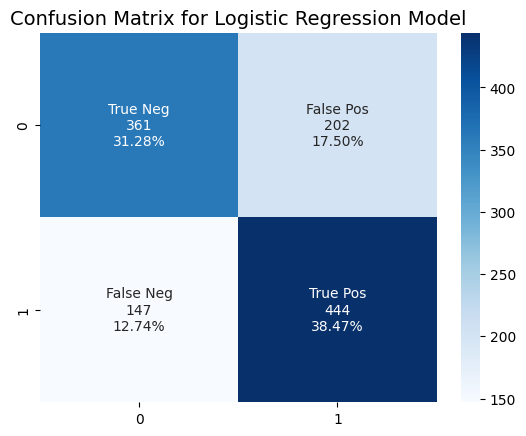

In [ ]:
# -- Split train and evaluate
X = matches_logreg[['win_rate_diff']]
y = matches_logreg.home_win

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.225, random_state=42, stratify=y)

# -- instantiate and fit
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

# -- Score
print("Train score:", logreg.score(X_train, y_train))
print("Validation score:", logreg.score(X_val, y_val))

cfm = confusion_matrix(y_val, logreg.predict(X_val))

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in cfm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cfm.flatten()/np.sum(cfm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(cfm.shape)

# Plot
sns.heatmap(cfm, annot=labels, fmt='', cmap='Blues')
plt.title("Confusion Matrix for Logistic Regression Model",fontsize=14)
plt.show()

Train scores: [0.7064846416382252, 0.6999024865919063, 0.7008776206728425, 0.7124055569095784, 0.7097245917621253]
Fold Validation scores: [0.7037037037037037, 0.7309941520467836, 0.7241715399610137, 0.6809756097560976, 0.688780487804878]
Mean CV Validation score: 0.7057250986544954


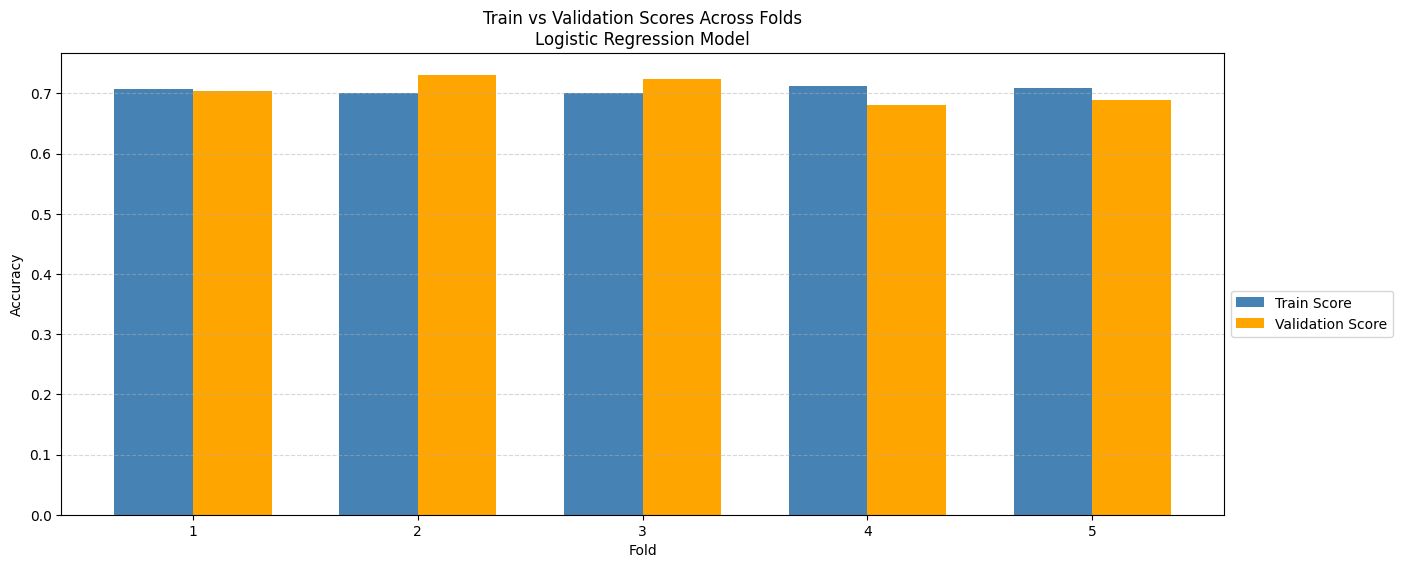

In [ ]:
# -- Cross validate model
kf = KFold(n_splits=5, shuffle=True, random_state=42)

val_scores = []
train_scores = []

for train_idx, val_idx in kf.split(X):
    # Split
    X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Fit model
    logreg.fit(X_train, y_train)

    # Score
    fold_score = logreg.score(X_val, y_val)
    train_score = logreg.score(X_train, y_train)

    val_scores.append(fold_score)
    train_scores.append(train_score)

print("Train scores:", train_scores)
print("Fold Validation scores:", val_scores)
print("Mean CV Validation score:", np.mean(val_scores))

folds = np.arange(1, len(train_scores) + 1)

plt.figure(figsize=(15, 6))
width = 0.35

plt.bar(folds - width/2, train_scores, width=width, label='Train Score', color='steelblue')
plt.bar(folds + width/2, val_scores,   width=width, label='Validation Score', color='orange')

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Scores Across Folds\nLogistic Regression Model")
plt.xticks(folds)
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [ ]:
# -- Coefficients
print("Intercept:", logreg.intercept_)
print("Coefficients:", logreg.coef_)

Intercept: [0.01019587]
Coefficients: [[2.17763128]]


In [ ]:
# Save model
import pickle
filename = 'logreg_model_OFFICIAL.pkl'

with open(filename, 'wb') as file:
    pickle.dump(logreg, file)

# DECISION TREE Model -- NO RANK RELATED FEATURES

In [ ]:
matches_w_stats.columns

Index(['dual_id', 'weight_class', 'event_date', 'home_wrestler_id',
       'home_name', 'home_rank', 'away_wrestler_id', 'away_name', 'away_rank',
       'home_win', 'win_type', 'Result', 'home_class', 'home_team_name',
       'away_class', 'away_team_name', 'home_matches_wrestled',
       'home_win_rate', 'home_loss_rate', 'home_bonus_rate', 'home_pin_count',
       'home_avg_opponent_rank', 'home_avg_point_diff',
       'home_avg_points_scored', 'home_std_point_diff',
       'away_matches_wrestled', 'away_win_rate', 'away_loss_rate',
       'away_bonus_rate', 'away_pin_count', 'away_avg_opponent_rank',
       'away_avg_point_diff', 'away_avg_points_scored', 'away_std_point_diff',
       'home_team_id', 'away_team_id', 'home_team_rank', 'away_team_rank',
       'wrestled_before', 'home_point_diff_rematches', 'home_pinned_away'],
      dtype='object')

In [ ]:
# -- GET FEATURE, and target
dt_df = matches_w_stats[["home_win", "weight_class", "home_class", "away_class", "home_matches_wrestled", "home_win_rate", "home_bonus_rate", "home_pin_count", "home_avg_point_diff", "home_avg_points_scored", "home_std_point_diff",
                 'away_matches_wrestled', 'away_win_rate', 'away_bonus_rate', 'away_pin_count', 'away_avg_point_diff', 'away_avg_points_scored', 'away_std_point_diff',
                 'wrestled_before', 'home_point_diff_rematches', 'home_pinned_away']]
dt_df

,home_win,weight_class,home_class,away_class,home_matches_wrestled,home_win_rate,home_bonus_rate,home_pin_count,home_avg_point_diff,home_avg_points_scored,...,away_matches_wrestled,away_win_rate,away_bonus_rate,away_pin_count,away_avg_point_diff,away_avg_points_scored,away_std_point_diff,wrestled_before,home_point_diff_rematches,home_pinned_away
0,1,174,JR,RSFR,1,1.000000,0.000000,0.0,3.000000,4.000000,...,0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0.0,0
1,1,285,SR,RSFR,1,1.000000,1.000000,0.0,15.000000,21.000000,...,1,0.000000,0.000000,0.0,-11.000000,1.000000,0.000000,0,0.0,0
2,0,184,SO,JR,0,0.000000,0.000000,0.0,0.000000,0.000000,...,1,0.000000,0.000000,0.0,-3.000000,7.000000,0.000000,0,0.0,0
3,0,149,FR,SR,1,0.000000,0.000000,0.0,-3.000000,9.000000,...,0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0.0,0
4,0,133,FR,SR,1,0.000000,0.000000,0.0,0.000000,0.000000,...,0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5123,0,125,SO,SR,8,0.125000,0.000000,0.0,-8.000000,6.400000,...,3,0.000000,0.000000,0.0,-11.000000,0.666667,3.605551,0,0.0,0
5124,1,133,FR,SO,2,0.000000,0.000000,0.0,-15.000000,2.000000,...,6,0.333333,0.166667,0.0,-0.500000,6.000000,10.408330,0,0.0,0
5125,0,165,JR,SR,2,0.000000,0.000000,0.0,-15.000000,0.500000,...,8,0.375000,0.125000,0.0,-1.714286,5.000000,8.138679,0,0.0,0
5126,0,174,SO,FR,12,0.000000,0.000000,0.0,-10.100000,2.600000,...,12,0.166667,0.166667,1.0,-3.909091,4.636364,7.687061,0,0.0,0


In [ ]:
# -- dummy variables for weight_class, home_class, and away_class
dummy_cols = ["weight_class", "home_class", 'away_class']
for col in dummy_cols:
  dummy_temp = pd.get_dummies(dt_df[col], prefix=col, drop_first=True).astype('int')
  dt_df = pd.concat([dt_df, dummy_temp], axis=1)
  dt_df = dt_df.drop(col, axis=1)

dt_df

,home_win,home_matches_wrestled,home_win_rate,home_bonus_rate,home_pin_count,home_avg_point_diff,home_avg_points_scored,home_std_point_diff,away_matches_wrestled,away_win_rate,...,home_class_RSSR,home_class_SO,home_class_SR,away_class_JR,away_class_RSFR,away_class_RSJR,away_class_RSSO,away_class_RSSR,away_class_SO,away_class_SR
0,1,1,1.000000,0.000000,0.0,3.000000,4.000000,0.000000,0,0.000000,...,0,0,0,0,1,0,0,0,0,0
1,1,1,1.000000,1.000000,0.0,15.000000,21.000000,0.000000,1,0.000000,...,0,0,1,0,1,0,0,0,0,0
2,0,0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1,0.000000,...,0,1,0,1,0,0,0,0,0,0
3,0,1,0.000000,0.000000,0.0,-3.000000,9.000000,0.000000,0,0.000000,...,0,0,0,0,0,0,0,0,0,1
4,0,1,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0.000000,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5123,0,8,0.125000,0.000000,0.0,-8.000000,6.400000,9.327379,3,0.000000,...,0,1,0,0,0,0,0,0,0,1
5124,1,2,0.000000,0.000000,0.0,-15.000000,2.000000,0.000000,6,0.333333,...,0,0,0,0,0,0,0,0,1,0
5125,0,2,0.000000,0.000000,0.0,-15.000000,0.500000,0.000000,8,0.375000,...,0,0,0,0,0,0,0,0,0,1
5126,0,12,0.000000,0.000000,0.0,-10.100000,2.600000,3.725289,12,0.166667,...,0,1,0,0,0,0,0,0,0,0


In [ ]:
# -- model no rank feature colums
dt_df.columns[1:]

Index(['home_matches_wrestled', 'home_win_rate', 'home_bonus_rate',
       'home_pin_count', 'home_avg_point_diff', 'home_avg_points_scored',
       'home_std_point_diff', 'away_matches_wrestled', 'away_win_rate',
       'away_bonus_rate', 'away_pin_count', 'away_avg_point_diff',
       'away_avg_points_scored', 'away_std_point_diff', 'wrestled_before',
       'home_point_diff_rematches', 'home_pinned_away', 'weight_class_133',
       'weight_class_141', 'weight_class_149', 'weight_class_157',
       'weight_class_165', 'weight_class_174', 'weight_class_184',
       'weight_class_197', 'weight_class_285', 'home_class_JR',
       'home_class_RSFR', 'home_class_RSJR', 'home_class_RSSO',
       'home_class_RSSR', 'home_class_SO', 'home_class_SR', 'away_class_JR',
       'away_class_RSFR', 'away_class_RSJR', 'away_class_RSSO',
       'away_class_RSSR', 'away_class_SO', 'away_class_SR'],
      dtype='object')

In [ ]:
# ============================================
# CREATE DIFFERENTIAL FEATURES
# ============================================

def create_differential_features(df):
    """
    Create differential features by subtracting away stats from home stats.
    Keep dummy variables as is.
    """
    df_diff = df.copy()

    # List of paired stat columns (home, away)
    stat_pairs = [
        ('home_matches_wrestled', 'away_matches_wrestled', 'matches_wrestled_diff'),
        ('home_win_rate', 'away_win_rate', 'win_rate_diff'),
        ('home_bonus_rate', 'away_bonus_rate', 'bonus_rate_diff'),
        ('home_pin_count', 'away_pin_count', 'pin_count_diff'),
        ('home_avg_point_diff', 'away_avg_point_diff', 'avg_point_diff_diff'),
        ('home_avg_points_scored', 'away_avg_points_scored', 'avg_points_scored_diff'),
        ('home_std_point_diff', 'away_std_point_diff', 'std_point_diff_diff')
    ]

    # Create differential features
    for home_col, away_col, new_col in stat_pairs:
        df_diff[new_col] = df_diff[home_col] - df_diff[away_col]
        print(f"✓ Created {new_col}")

    # Drop original home and away stat columns (keep target and dummies)
    cols_to_drop = []
    for home_col, away_col, _ in stat_pairs:
        cols_to_drop.extend([home_col, away_col])

    # Also drop other non-differential columns we don't need
    # (keeping wrestled_before, home_point_diff_rematches, home_pinned_away as they're already differential-like)

    df_diff = df_diff.drop(columns=cols_to_drop)

    print(f"\nFinal feature set: {df_diff.shape[1]-1} features (excluding target)")
    return df_diff

# Apply to your dataframe
dt_df_diff = create_differential_features(dt_df)

# Check the new columns
print("\n" + "="*80)
print("FEATURES AFTER DIFFERENTIAL CREATION")
print("="*80)
print(dt_df_diff.columns)

dt_df_diff

✓ Created matches_wrestled_diff
✓ Created win_rate_diff
✓ Created bonus_rate_diff
✓ Created pin_count_diff
✓ Created avg_point_diff_diff
✓ Created avg_points_scored_diff
✓ Created std_point_diff_diff

Final feature set: 33 features (excluding target)

FEATURES AFTER DIFFERENTIAL CREATION
Index(['home_win', 'wrestled_before', 'home_point_diff_rematches',
       'home_pinned_away', 'weight_class_133', 'weight_class_141',
       'weight_class_149', 'weight_class_157', 'weight_class_165',
       'weight_class_174', 'weight_class_184', 'weight_class_197',
       'weight_class_285', 'home_class_JR', 'home_class_RSFR',
       'home_class_RSJR', 'home_class_RSSO', 'home_class_RSSR',
       'home_class_SO', 'home_class_SR', 'away_class_JR', 'away_class_RSFR',
       'away_class_RSJR', 'away_class_RSSO', 'away_class_RSSR',
       'away_class_SO', 'away_class_SR', 'matches_wrestled_diff',
       'win_rate_diff', 'bonus_rate_diff', 'pin_count_diff',
       'avg_point_diff_diff', 'avg_points_scored

,home_win,wrestled_before,home_point_diff_rematches,home_pinned_away,weight_class_133,weight_class_141,weight_class_149,weight_class_157,weight_class_165,weight_class_174,...,away_class_RSSR,away_class_SO,away_class_SR,matches_wrestled_diff,win_rate_diff,bonus_rate_diff,pin_count_diff,avg_point_diff_diff,avg_points_scored_diff,std_point_diff_diff
0,1,0,0.0,0,0,0,0,0,0,1,...,0,0,0,1,1.000000,0.000000,0.0,3.000000,4.000000,0.000000
1,1,0,0.0,0,0,0,0,0,0,0,...,0,0,0,0,1.000000,1.000000,0.0,26.000000,20.000000,0.000000
2,0,0,0.0,0,0,0,0,0,0,0,...,0,0,0,-1,0.000000,0.000000,0.0,3.000000,-7.000000,0.000000
3,0,0,0.0,0,0,0,1,0,0,0,...,0,0,1,1,0.000000,0.000000,0.0,-3.000000,9.000000,0.000000
4,0,0,0.0,0,1,0,0,0,0,0,...,0,0,1,1,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5123,0,0,0.0,0,0,0,0,0,0,0,...,0,0,1,5,0.125000,0.000000,0.0,3.000000,5.733333,5.721828
5124,1,0,0.0,0,1,0,0,0,0,0,...,0,1,0,-4,-0.333333,-0.166667,0.0,-14.500000,-4.000000,-10.408330
5125,0,0,0.0,0,0,0,0,0,1,0,...,0,0,1,-6,-0.375000,-0.125000,0.0,-13.285714,-4.500000,-8.138679
5126,0,0,0.0,0,0,0,0,0,0,1,...,0,0,0,0,-0.166667,-0.166667,-1.0,-6.190909,-2.036364,-3.961772


DECISION TREE HYPERPARAMETER TUNING
Training set: (3974, 33)
Validation set: (1154, 33)

INITIAL MODEL (DEFAULT PARAMETERS)
Train accuracy: 1.0000
Validation accuracy: 0.6144
Overfitting: 0.3856

HYPERPARAMETER TUNING
Searching 100 parameter combinations...
Fitting 5 folds for each of 33 candidates, totalling 165 fits

Best CV Score: 0.7136
Best Parameters: {'splitter': 'best', 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 3, 'criterion': 'entropy', 'ccp_alpha': 0.001}

Tuned Model - Train accuracy: 0.7189
Tuned Model - Validation accuracy: 0.7080
Improvement: 0.0936
Overfitting reduced: 0.3747

FEATURE IMPORTANCE

Top 15 most important features:
                  feature  importance
      avg_point_diff_diff    0.754129
            win_rate_diff    0.222022
    matches_wrestled_diff    0.023849
          wrestled_before    0.000000
home_point_diff_rematches    0.000000
         weight_class_149    0.000000
         home_pinned_away    0.000000
    

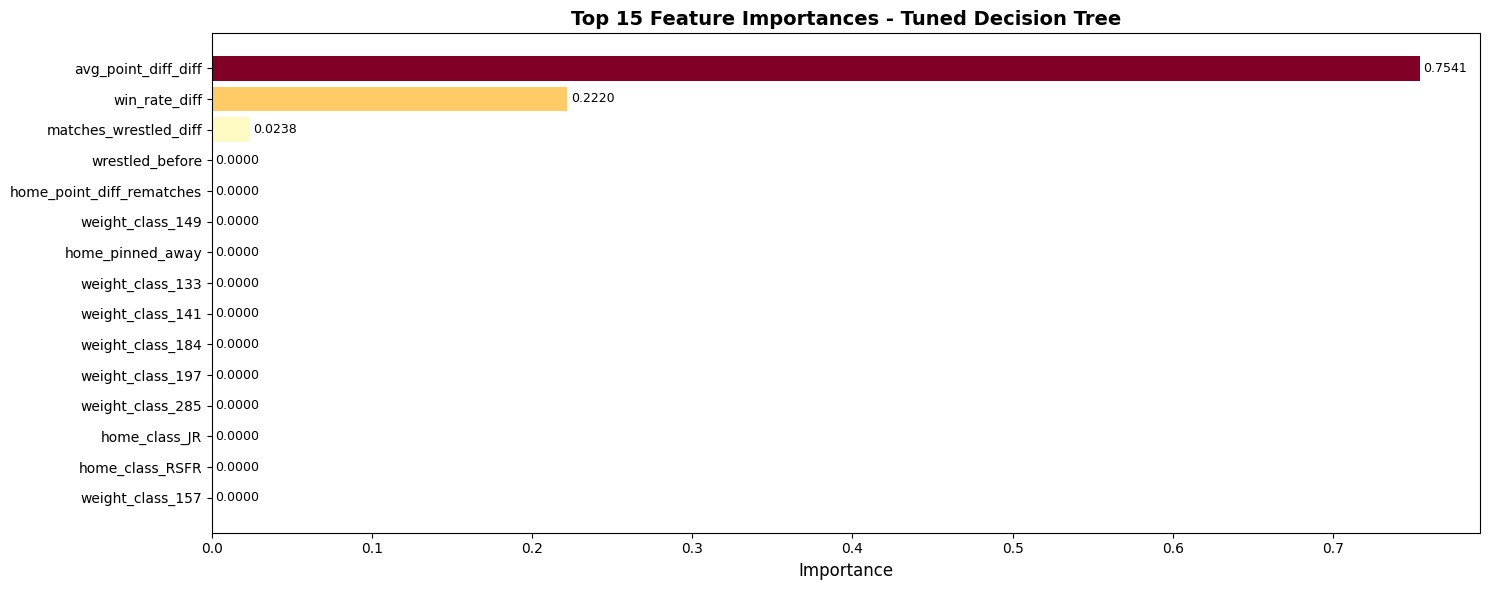


CONFUSION MATRIX


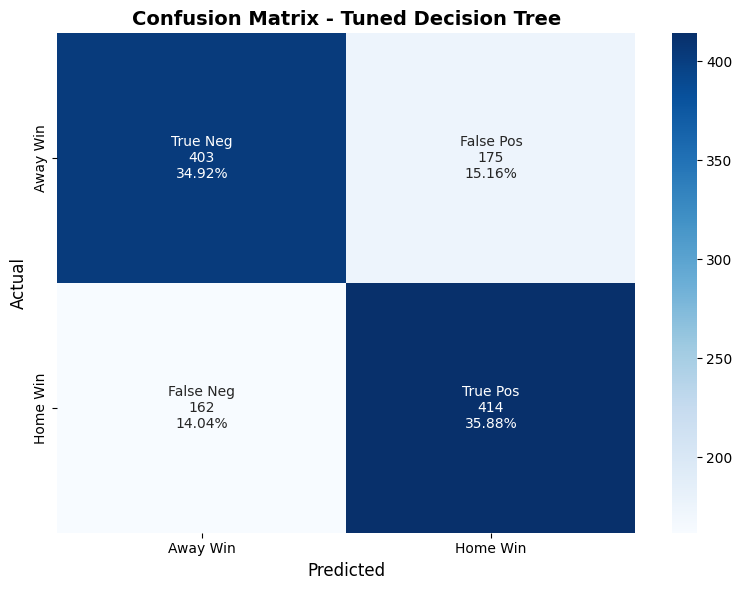


Accuracy: 0.7080
Precision: 0.7029
Recall: 0.7188
F1 Score: 0.7107

DECISION TREE VISUALIZATION


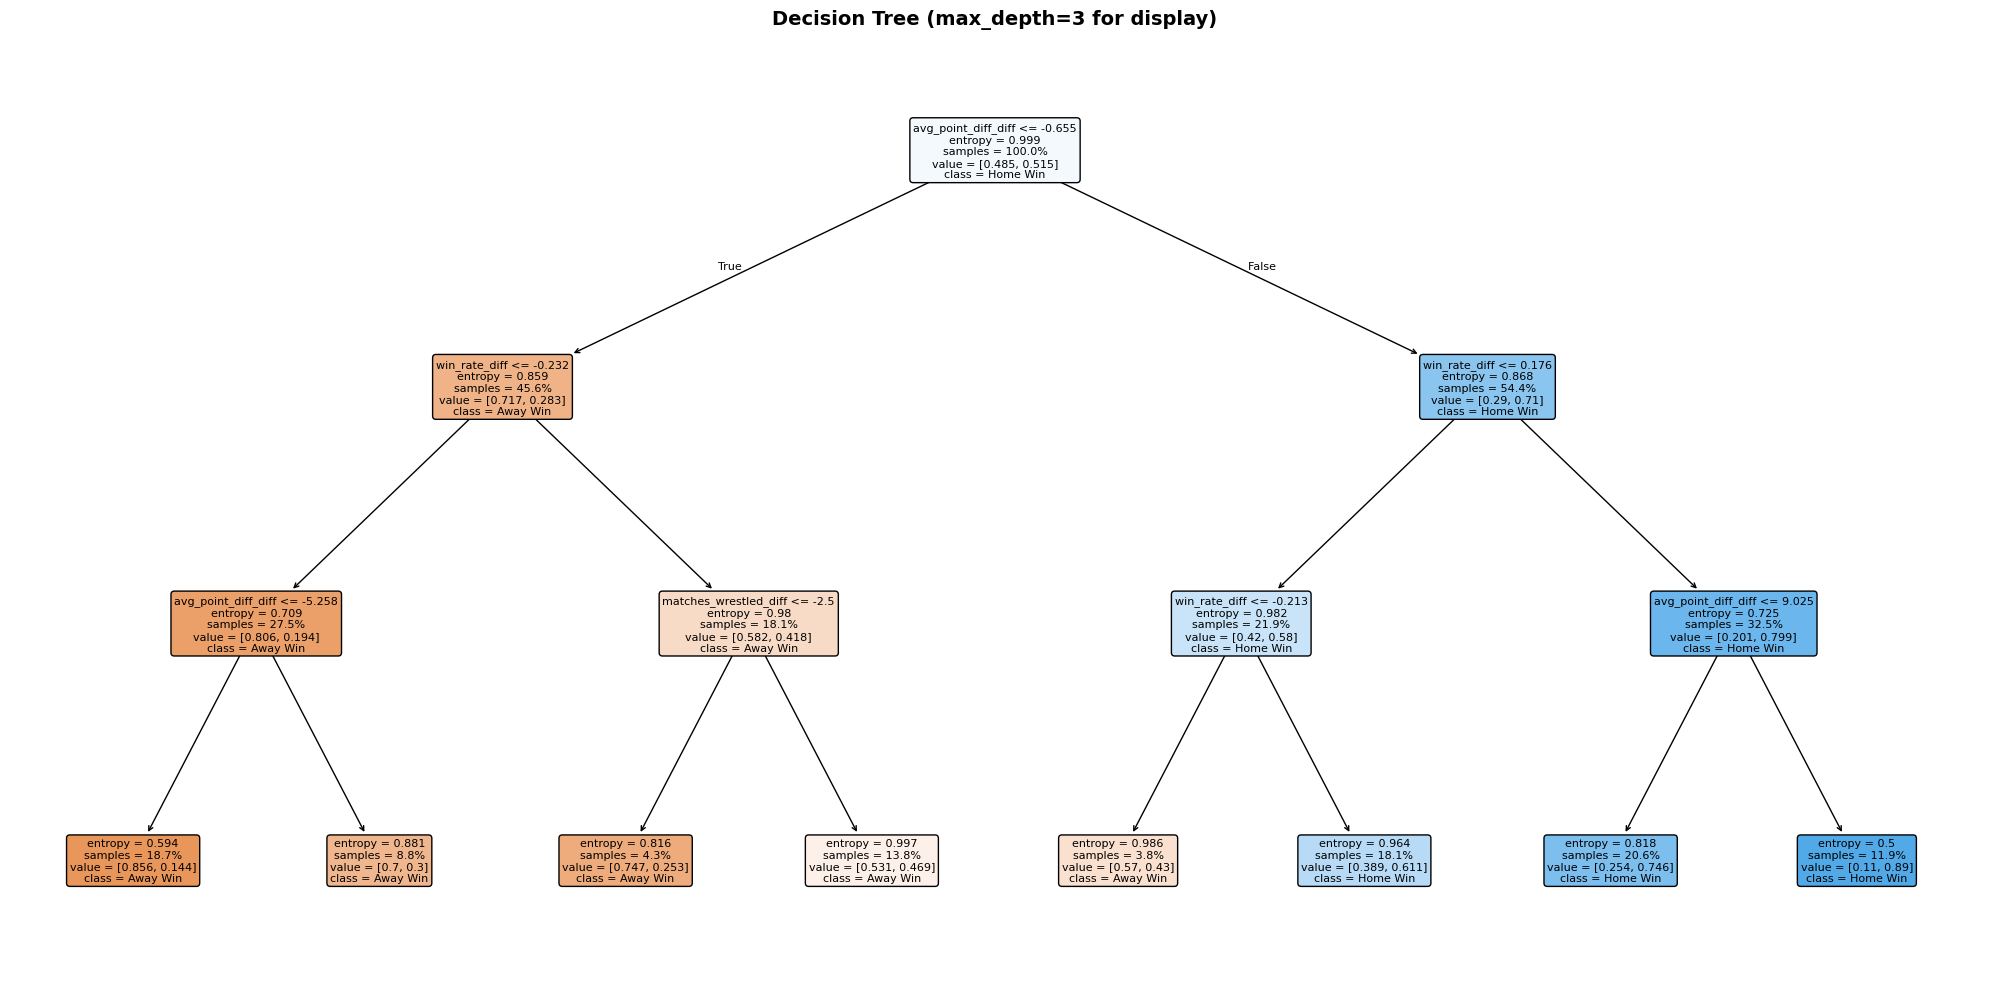

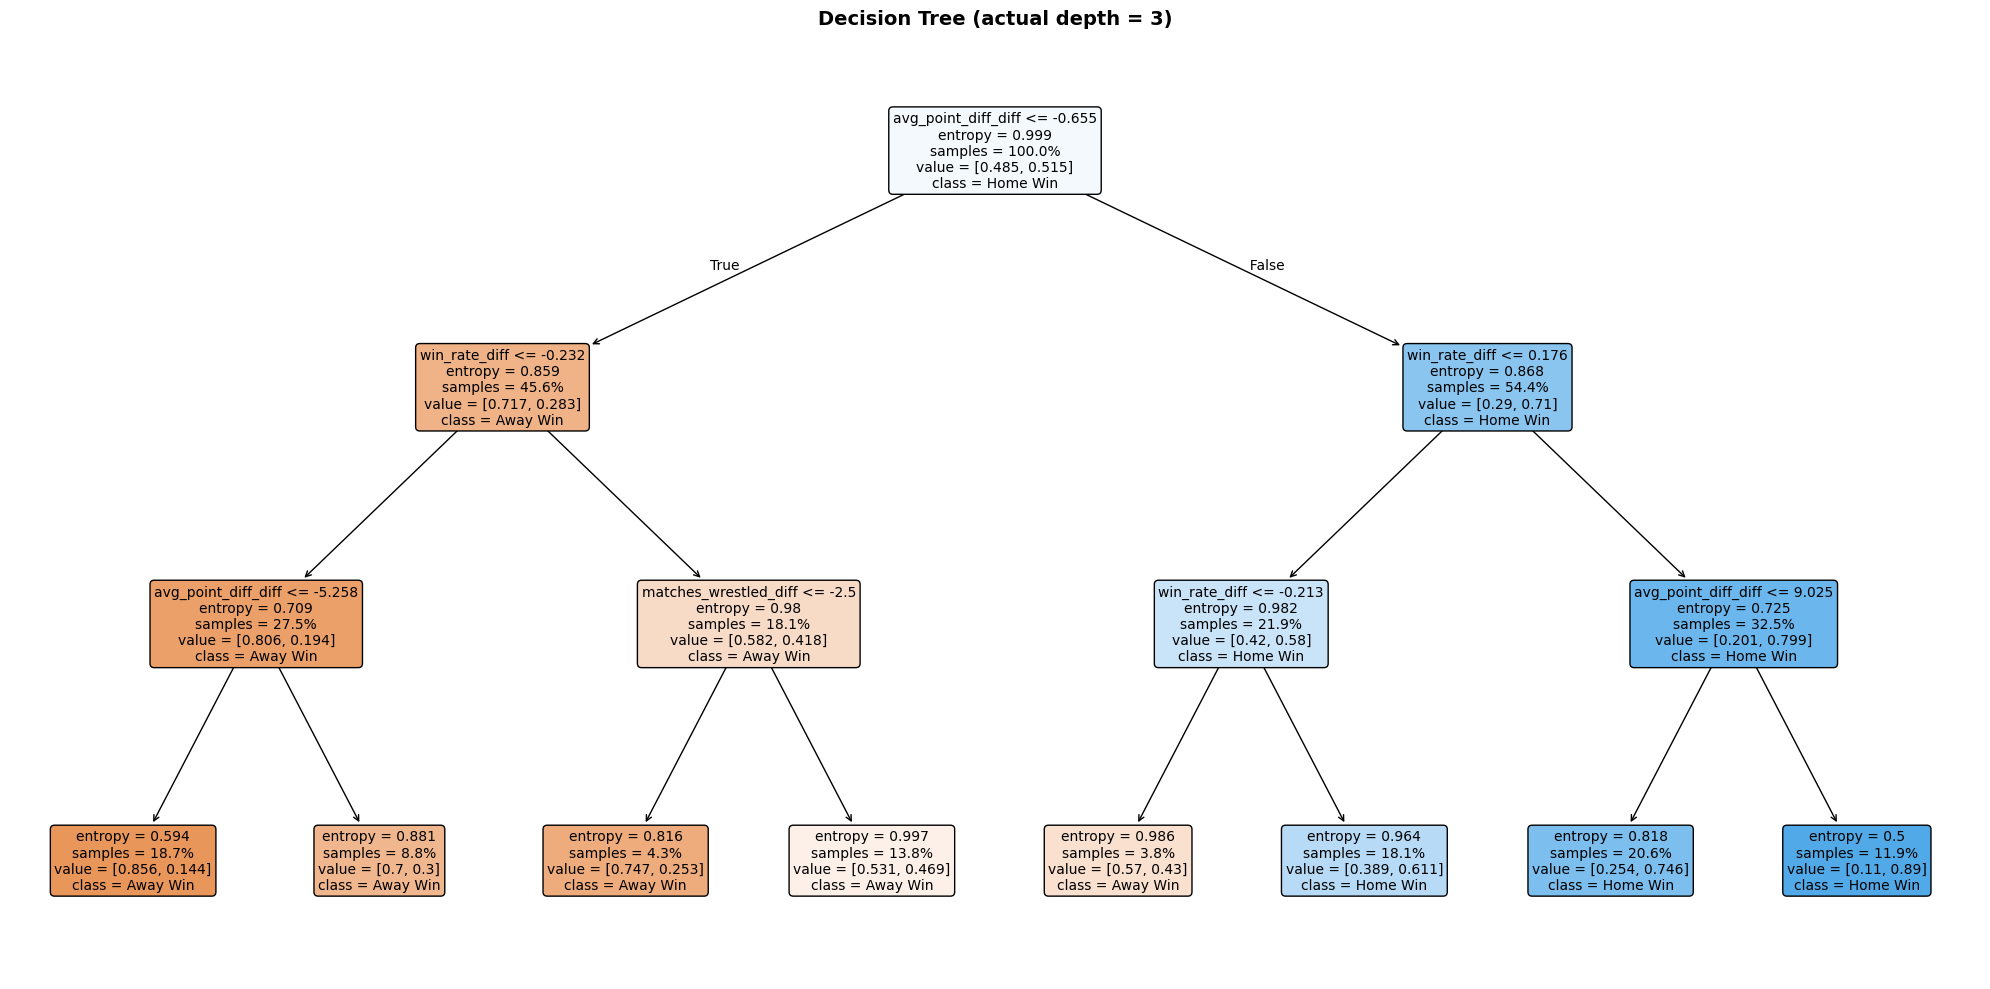


CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Away Win       0.71      0.70      0.71       578
    Home Win       0.70      0.72      0.71       576

    accuracy                           0.71      1154
   macro avg       0.71      0.71      0.71      1154
weighted avg       0.71      0.71      0.71      1154


MODEL COMPARISON
                Model Train Accuracy Validation Accuracy Overfitting CV Score
Initial Decision Tree         1.0000              0.6144      0.3856      N/A
  Tuned Decision Tree         0.7189              0.7080      0.0110   0.7136

✅ Saved tuned Decision Tree to dt_model_tuned_OFFICIAL.pkl

✅ DECISION TREE TUNING COMPLETE


In [ ]:
# ============================================
# PREPARE DATA
# ============================================
print("="*80)
print("DECISION TREE HYPERPARAMETER TUNING")
print("="*80)

#X, y = dt_df[[col for col in dt_df.columns if col != 'home_win']], dt_df.home_win
X, y = dt_df_diff.drop(columns=['home_win']), dt_df_diff.home_win
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.225, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")

# ============================================
# INITIAL MODEL (for comparison)
# ============================================
print("\n" + "="*80)
print("INITIAL MODEL (DEFAULT PARAMETERS)")
print("="*80)

dt_initial = DecisionTreeClassifier(random_state=42)
dt_initial.fit(X_train, y_train)

train_score = dt_initial.score(X_train, y_train)
val_score = dt_initial.score(X_val, y_val)

print(f"Train accuracy: {train_score:.4f}")
print(f"Validation accuracy: {val_score:.4f}")
print(f"Overfitting: {train_score - val_score:.4f}")

# ============================================
# HYPERPARAMETER TUNING WITH RANDOMIZEDSEARCHCV
# ============================================
print("\n" + "="*80)
print("HYPERPARAMETER TUNING")
print("="*80)

# Define parameter distribution
param_dist = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10, 12, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15, 20, 30, 50],
    'min_samples_leaf': [1, 2, 5, 10, 15, 20],
    'max_features': [None, 'sqrt', 'log2'],
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.05, 0.1]
}

# Create base model
dt_base = DecisionTreeClassifier(random_state=42)

# Create RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=dt_base,
    param_distributions=param_dist,
    n_iter=33,  # Number of parameter combinations to try
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Searching 100 parameter combinations...")
random_search.fit(X_train, y_train)

# Best model
best_dt = random_search.best_estimator_
best_params = random_search.best_params_
best_cv_score = random_search.best_score_

print(f"\nBest CV Score: {best_cv_score:.4f}")
print(f"Best Parameters: {best_params}")

# Evaluate on validation set
train_score_tuned = best_dt.score(X_train, y_train)
val_score_tuned = best_dt.score(X_val, y_val)

print(f"\nTuned Model - Train accuracy: {train_score_tuned:.4f}")
print(f"Tuned Model - Validation accuracy: {val_score_tuned:.4f}")
print(f"Improvement: {val_score_tuned - val_score:.4f}")
print(f"Overfitting reduced: {(train_score - val_score) - (train_score_tuned - val_score_tuned):.4f}")

# ============================================
# FEATURE IMPORTANCE
# ============================================
print("\n" + "="*80)
print("FEATURE IMPORTANCE")
print("="*80)

feature_names = X.columns
importances = best_dt.feature_importances_

# Create importance dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nTop 15 most important features:")
print(importance_df.head(15).to_string(index=False))

# Plot top 15 features
plt.figure(figsize=(15, 6))
top_15 = importance_df.head(15)
colors = plt.cm.YlOrRd(top_15['importance'].values / top_15['importance'].max())
bars = plt.barh(range(len(top_15)), top_15['importance'].values, color=colors)
plt.yticks(range(len(top_15)), top_15['feature'].values)
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 Feature Importances - Tuned Decision Tree', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_15['importance'].values)):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('dt_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# CONFUSION MATRIX
# ============================================
print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)

y_pred = best_dt.predict(X_val)
cfm = confusion_matrix(y_val, y_pred)

# Create annotated confusion matrix
group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
group_counts = ["{0:0.0f}".format(value) for value in cfm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cfm.flatten()/np.sum(cfm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2, 2)

plt.figure(figsize=(8, 6))
sns.heatmap(cfm, annot=labels, fmt='', cmap='Blues',
            xticklabels=['Away Win', 'Home Win'],
            yticklabels=['Away Win', 'Home Win'])
plt.title('Confusion Matrix - Tuned Decision Tree', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('dt_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate metrics
tn, fp, fn, tp = cfm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# ============================================
# DECISION TREE VISUALIZATION
# ============================================
print("\n" + "="*80)
print("DECISION TREE VISUALIZATION")
print("="*80)

# Plot a simplified version of the tree (limited depth)
plt.figure(figsize=(20, 10))
plot_tree(
    best_dt,
    max_depth=3,  # Limit depth for readability
    feature_names=feature_names.tolist(),
    class_names=['Away Win', 'Home Win'],
    filled=True,
    rounded=True,
    fontsize=8,
    proportion=True
)
plt.title('Decision Tree (max_depth=3 for display)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_tree_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# Also plot a smaller tree if max_depth is low enough
if best_dt.get_params()['max_depth'] is not None and best_dt.get_params()['max_depth'] <= 5:
    plt.figure(figsize=(20, 10))
    plot_tree(
        best_dt,
        feature_names=feature_names.tolist(),
        class_names=['Away Win', 'Home Win'],
        filled=True,
        rounded=True,
        fontsize=10,
        proportion=True
    )
    plt.title(f'Decision Tree (actual depth = {best_dt.get_params()["max_depth"]})',
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('dt_tree_full.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================
# CLASSIFICATION REPORT
# ============================================
print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)

print(classification_report(y_val, y_pred, target_names=['Away Win', 'Home Win']))

# ============================================
# COMPARE INITIAL VS TUNED
# ============================================
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

comparison = pd.DataFrame({
    'Model': ['Initial Decision Tree', 'Tuned Decision Tree'],
    'Train Accuracy': [f"{train_score:.4f}", f"{train_score_tuned:.4f}"],
    'Validation Accuracy': [f"{val_score:.4f}", f"{val_score_tuned:.4f}"],
    'Overfitting': [f"{train_score - val_score:.4f}", f"{train_score_tuned - val_score_tuned:.4f}"],
    'CV Score': ['N/A', f"{best_cv_score:.4f}"]
})

print(comparison.to_string(index=False))

# ============================================
# SAVE MODEL
# ============================================
print("\n" + "="*80)
#print("SAVING MODEL")
print("="*80)

filename = 'dt_model_tuned_OFFICIAL.pkl'
with open(filename, 'wb') as f:
    pickle.dump(best_dt, f)
print(f"✅ Saved tuned Decision Tree to {filename}")

# # Save the random search object for reference
# search_filename = 'dt_random_search.pkl'
# with open(search_filename, 'wb') as f:
# #     pickle.dump(random_search, f)
# print(f"✅ Saved random search object to {search_filename}")

# # Save feature importance
# importance_df.to_csv('dt_feature_importance.csv', index=False)
# print("✅ Saved feature importance to dt_feature_importance.csv")

print("\n" + "="*80)
print("✅ DECISION TREE TUNING COMPLETE")
print("="*80)

# XGBOOST SEQUENTIAL MODEL

XGBOOST HYPERPARAMETER TUNING

INITIAL MODEL (DEFAULT PARAMETERS)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:22:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train accuracy: 0.9721
Validation accuracy: 0.6924
Overfitting: 0.2797

HYPERPARAMETER TUNING
Searching parameter combinations...
Fitting 5 folds for each of 33 candidates, totalling 165 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:22:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best CV Score: 0.7245
Best Parameters: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 10, 'n_estimators': 100, 'min_child_weight': 2, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.4, 'colsample_bytree': 0.8}

Tuned Model - Train accuracy: 0.7521
Tuned Model - Validation accuracy: 0.7140
Improvement: 0.0217
Overfitting reduced: 0.2416

FEATURE IMPORTANCE

Top 15 most important features:
               feature  importance
   avg_point_diff_diff    0.247388
         win_rate_diff    0.204272
       bonus_rate_diff    0.041068
         away_class_SR    0.034769
 matches_wrestled_diff    0.032031
         home_class_SR    0.027690
avg_points_scored_diff    0.026727
       away_class_RSFR    0.025242
       away_class_RSJR    0.023146
       home_class_RSSR    0.022698
   std_point_diff_diff    0.020363
       wrestled_before    0.018914
       home_class_RSJR    0.018053
      weight_class_197    0.018045
        pin_count_diff    0.017488


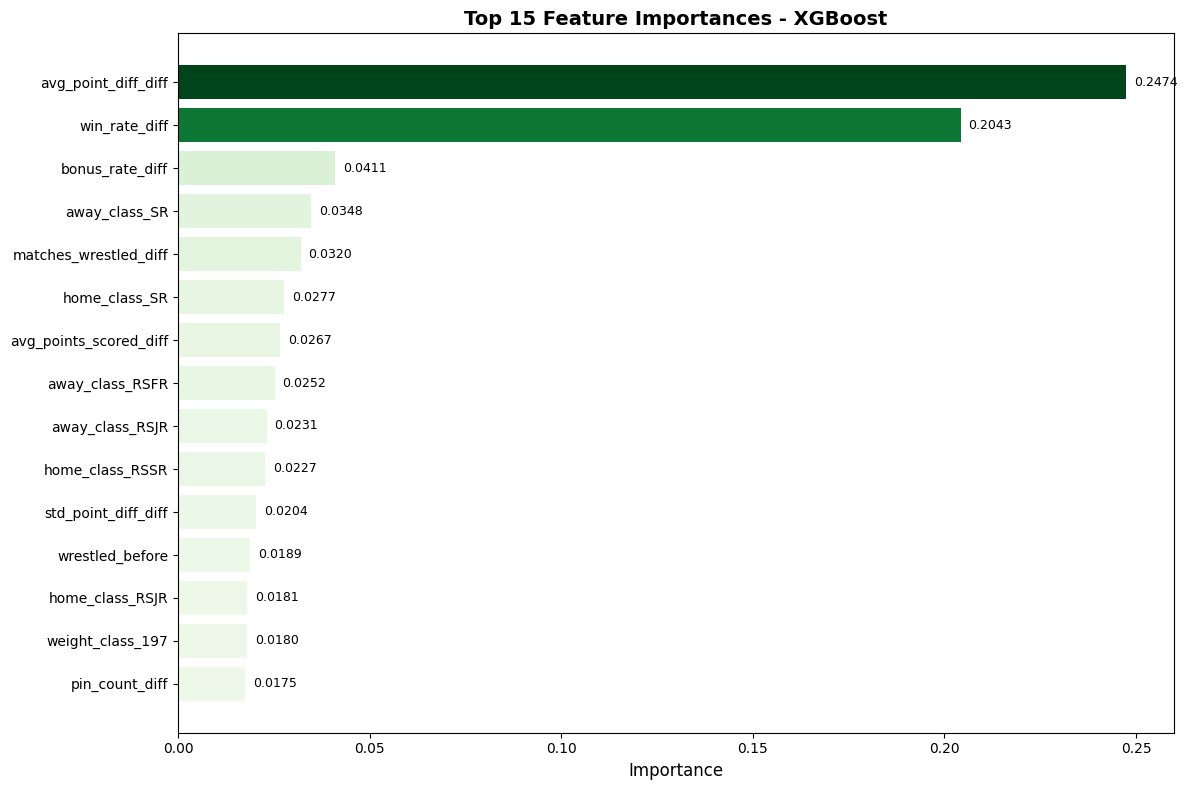


CONFUSION MATRIX


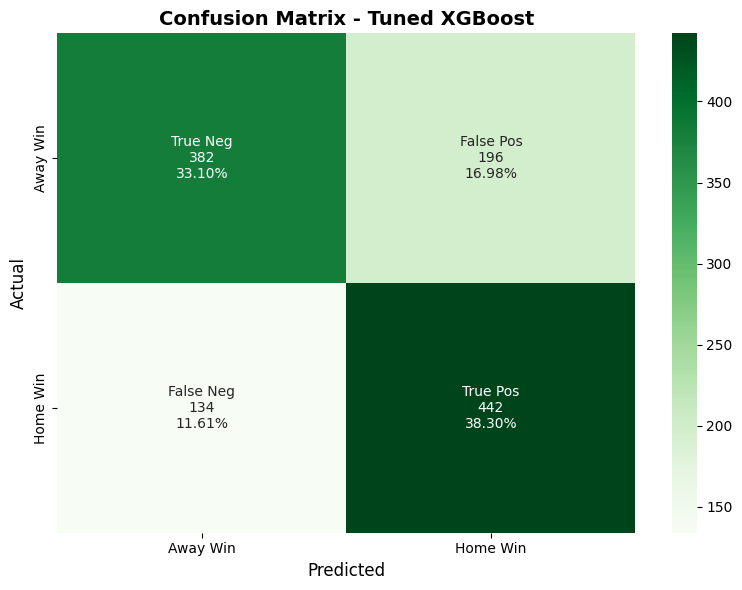


Accuracy: 0.7140
Precision: 0.6928
Recall: 0.7674
F1 Score: 0.7282

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Away Win       0.74      0.66      0.70       578
    Home Win       0.69      0.77      0.73       576

    accuracy                           0.71      1154
   macro avg       0.72      0.71      0.71      1154
weighted avg       0.72      0.71      0.71      1154


MODEL COMPARISON
          Model Train Accuracy Validation Accuracy Overfitting CV Score
Initial XGBoost         0.9721              0.6924      0.2797      N/A
  Tuned XGBoost         0.7521              0.7140      0.0381   0.7245

SAVING MODEL
✅ Saved tuned XGBoost to xgboost_model_tuned_noranks_OFFICIAL.pkl
✅ Saved random search object to xgboost_random_search_without_rank_OFFICIAL.pkl

✅ XGBOOST TUNING COMPLETE
Best Validation Accuracy: 0.7140
Best Parameters: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 10, 'n_estimators': 100, 'min_child_weight': 2, 'max_depth': 7

In [ ]:
# ============================================
# XGBOOST HYPERPARAMETER TUNING
# ============================================

print("="*80)
print("XGBOOST HYPERPARAMETER TUNING")
print("="*80)

# Your data is already split (X_train, X_val, y_train, y_val)

# ============================================
# INITIAL MODEL (for comparison)
# ============================================
print("\n" + "="*80)
print("INITIAL MODEL (DEFAULT PARAMETERS)")
print("="*80)

xgb_initial = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_initial.fit(X_train, y_train)

train_score = xgb_initial.score(X_train, y_train)
val_score = xgb_initial.score(X_val, y_val)

print(f"Train accuracy: {train_score:.4f}")
print(f"Validation accuracy: {val_score:.4f}")
print(f"Overfitting: {train_score - val_score:.4f}")

# ============================================
# HYPERPARAMETER TUNING
# ============================================
print("\n" + "="*80)
print("HYPERPARAMETER TUNING")
print("="*80)

# Parameter distribution for XGBoost
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 3, 4, 5],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'reg_alpha': [0, 0.01, 0.1, 1, 10],
    'reg_lambda': [0, 0.01, 0.1, 1, 10]
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=33,  # Number of parameter combinations to try
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Searching parameter combinations...")
random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_
best_params = random_search.best_params_
best_cv_score = random_search.best_score_

print(f"\nBest CV Score: {best_cv_score:.4f}")
print(f"Best Parameters: {best_params}")

# Evaluate on validation set
train_score_tuned = best_xgb.score(X_train, y_train)
val_score_tuned = best_xgb.score(X_val, y_val)

print(f"\nTuned Model - Train accuracy: {train_score_tuned:.4f}")
print(f"Tuned Model - Validation accuracy: {val_score_tuned:.4f}")
print(f"Improvement: {val_score_tuned - val_score:.4f}")
print(f"Overfitting reduced: {(train_score - val_score) - (train_score_tuned - val_score_tuned):.4f}")

# ============================================
# FEATURE IMPORTANCE
# ============================================
print("\n" + "="*80)
print("FEATURE IMPORTANCE")
print("="*80)

feature_names = X_train.columns.tolist()
importances = best_xgb.feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nTop 15 most important features:")
print(importance_df.head(15).to_string(index=False))

# Plot top 15 features
plt.figure(figsize=(12, 8))
top_15 = importance_df.head(15)
colors = plt.cm.Greens(top_15['importance'].values / top_15['importance'].max())
bars = plt.barh(range(len(top_15)), top_15['importance'].values, color=colors)
plt.yticks(range(len(top_15)), top_15['feature'].values)
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 Feature Importances - XGBoost', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_15['importance'].values)):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================
# CONFUSION MATRIX
# ============================================
print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)

y_pred = best_xgb.predict(X_val)
cfm = confusion_matrix(y_val, y_pred)

# Create annotated confusion matrix
group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
group_counts = ["{0:0.0f}".format(value) for value in cfm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cfm.flatten()/np.sum(cfm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2, 2)

plt.figure(figsize=(8, 6))
sns.heatmap(cfm, annot=labels, fmt='', cmap='Greens',
            xticklabels=['Away Win', 'Home Win'],
            yticklabels=['Away Win', 'Home Win'])
plt.title('Confusion Matrix - Tuned XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate metrics
tn, fp, fn, tp = cfm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# ============================================
# CLASSIFICATION REPORT
# ============================================
print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)

print(classification_report(y_val, y_pred, target_names=['Away Win', 'Home Win']))

# ============================================
# COMPARE INITIAL VS TUNED
# ============================================
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

comparison = pd.DataFrame({
    'Model': ['Initial XGBoost', 'Tuned XGBoost'],
    'Train Accuracy': [f"{train_score:.4f}", f"{train_score_tuned:.4f}"],
    'Validation Accuracy': [f"{val_score:.4f}", f"{val_score_tuned:.4f}"],
    'Overfitting': [f"{train_score - val_score:.4f}", f"{train_score_tuned - val_score_tuned:.4f}"],
    'CV Score': ['N/A', f"{best_cv_score:.4f}"]
})

print(comparison.to_string(index=False))

# ============================================
# SAVE MODEL
# ============================================
print("\n" + "="*80)
print("SAVING MODEL")
print("="*80)

filename = 'xgboost_model_tuned_noranks_OFFICIAL.pkl'
with open(filename, 'wb') as f:
    pickle.dump(best_xgb, f)
print(f"✅ Saved tuned XGBoost to {filename}")

# # Save the random search object
search_filename = 'xgboost_random_search_without_rank_OFFICIAL.pkl'
with open(search_filename, 'wb') as f:
    pickle.dump(random_search, f)
print(f"✅ Saved random search object to {search_filename}")

# # Save feature importance
# importance_df.to_csv('xgboost_feature_importance.csv', index=False)
# print("✅ Saved feature importance to xgboost_feature_importance.csv")

print("\n" + "="*80)
print("✅ XGBOOST TUNING COMPLETE")
print("="*80)
print(f"Best Validation Accuracy: {val_score_tuned:.4f}")
print(f"Best Parameters: {best_params}")

In [ ]:
X_train.columns

Index(['wrestled_before', 'home_point_diff_rematches', 'home_pinned_away',
       'weight_class_133', 'weight_class_141', 'weight_class_149',
       'weight_class_157', 'weight_class_165', 'weight_class_174',
       'weight_class_184', 'weight_class_197', 'weight_class_285',
       'home_class_JR', 'home_class_RSFR', 'home_class_RSJR',
       'home_class_RSSO', 'home_class_RSSR', 'home_class_SO', 'home_class_SR',
       'away_class_JR', 'away_class_RSFR', 'away_class_RSJR',
       'away_class_RSSO', 'away_class_RSSR', 'away_class_SO', 'away_class_SR',
       'matches_wrestled_diff', 'win_rate_diff', 'bonus_rate_diff',
       'pin_count_diff', 'avg_point_diff_diff', 'avg_points_scored_diff',
       'std_point_diff_diff'],
      dtype='object')

In [ ]:
X_train_cols_dt_xgb1 = X_train.columns.tolist()
with open("features_dt_xgb1.pkl", "wb") as f:
    pickle.dump(X_train_cols_dt_xgb1, f)

In [ ]:
print(X_train_cols_dt_xgb1)
print(len(X_train_cols_dt_xgb1))

['wrestled_before', 'home_point_diff_rematches', 'home_pinned_away', 'weight_class_133', 'weight_class_141', 'weight_class_149', 'weight_class_157', 'weight_class_165', 'weight_class_174', 'weight_class_184', 'weight_class_197', 'weight_class_285', 'home_class_JR', 'home_class_RSFR', 'home_class_RSJR', 'home_class_RSSO', 'home_class_RSSR', 'home_class_SO', 'home_class_SR', 'away_class_JR', 'away_class_RSFR', 'away_class_RSJR', 'away_class_RSSO', 'away_class_RSSR', 'away_class_SO', 'away_class_SR', 'matches_wrestled_diff', 'win_rate_diff', 'bonus_rate_diff', 'pin_count_diff', 'avg_point_diff_diff', 'avg_points_scored_diff', 'std_point_diff_diff']
33


# Now, very controversially, I will add rank into the picture, not individual rank however

In [ ]:
matches_w_stats.columns

Index(['dual_id', 'weight_class', 'event_date', 'home_wrestler_id',
       'home_name', 'home_rank', 'away_wrestler_id', 'away_name', 'away_rank',
       'home_win', 'win_type', 'Result', 'home_class', 'home_team_name',
       'away_class', 'away_team_name', 'home_matches_wrestled',
       'home_win_rate', 'home_loss_rate', 'home_bonus_rate', 'home_pin_count',
       'home_avg_opponent_rank', 'home_avg_point_diff',
       'home_avg_points_scored', 'home_std_point_diff',
       'away_matches_wrestled', 'away_win_rate', 'away_loss_rate',
       'away_bonus_rate', 'away_pin_count', 'away_avg_opponent_rank',
       'away_avg_point_diff', 'away_avg_points_scored', 'away_std_point_diff',
       'home_team_id', 'away_team_id', 'home_team_rank', 'away_team_rank',
       'wrestled_before', 'home_point_diff_rematches', 'home_pinned_away'],
      dtype='object')

In [ ]:
xgb_df = matches_w_stats[["home_win", "weight_class", "home_class", "away_class", 'home_matches_wrestled',
       'home_win_rate', 'home_loss_rate', 'home_bonus_rate', 'home_pin_count',
       'home_avg_point_diff',
       'home_avg_points_scored', 'home_std_point_diff',
       'away_matches_wrestled', 'away_win_rate', 'away_loss_rate',
       'away_bonus_rate', 'away_pin_count',
       'away_avg_point_diff', 'away_avg_points_scored', 'away_std_point_diff', 'home_team_rank', 'away_team_rank',
       'wrestled_before', 'home_point_diff_rematches', 'home_pinned_away']]

xgb_df

,home_win,weight_class,home_class,away_class,home_matches_wrestled,home_win_rate,home_loss_rate,home_bonus_rate,home_pin_count,home_avg_point_diff,...,away_bonus_rate,away_pin_count,away_avg_point_diff,away_avg_points_scored,away_std_point_diff,home_team_rank,away_team_rank,wrestled_before,home_point_diff_rematches,home_pinned_away
0,1,174,JR,RSFR,1,1.000000,0.000000,0.000000,0.0,3.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,68,16,0,0.0,0
1,1,285,SR,RSFR,1,1.000000,0.000000,1.000000,0.0,15.000000,...,0.000000,0.0,-11.000000,1.000000,0.000000,16,67,0,0.0,0
2,0,184,SO,JR,0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,-3.000000,7.000000,0.000000,70,32,0,0.0,0
3,0,149,FR,SR,1,0.000000,1.000000,0.000000,0.0,-3.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,68,16,0,0.0,0
4,0,133,FR,SR,1,0.000000,1.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,68,16,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5123,0,125,SO,SR,8,0.125000,0.875000,0.000000,0.0,-8.000000,...,0.000000,0.0,-11.000000,0.666667,3.605551,78,71,0,0.0,0
5124,1,133,FR,SO,2,0.000000,1.000000,0.000000,0.0,-15.000000,...,0.166667,0.0,-0.500000,6.000000,10.408330,78,71,0,0.0,0
5125,0,165,JR,SR,2,0.000000,1.000000,0.000000,0.0,-15.000000,...,0.125000,0.0,-1.714286,5.000000,8.138679,78,71,0,0.0,0
5126,0,174,SO,FR,12,0.000000,1.000000,0.000000,0.0,-10.100000,...,0.166667,1.0,-3.909091,4.636364,7.687061,78,71,0,0.0,0


In [ ]:
# ============================================
# PREPROCESS XGBOOST DATAFRAME
# ============================================

print("="*80)
print("PREPROCESSING XGBOOST DATAFRAME")
print("="*80)

# Make a copy
xgb_df_processed = xgb_df.copy()

# ============================================
# 1. CREATE DIFFERENTIAL FEATURES
# ============================================
print("\n📊 Creating differential features...")

# List of paired stats (home, away, new_name)
stat_pairs = [
    ('home_matches_wrestled', 'away_matches_wrestled', 'matches_wrestled_diff'),
    ('home_win_rate', 'away_win_rate', 'win_rate_diff'),
    ('home_bonus_rate', 'away_bonus_rate', 'bonus_rate_diff'),
    ('home_pin_count', 'away_pin_count', 'pin_count_diff'),
    ('home_avg_point_diff', 'away_avg_point_diff', 'avg_point_diff_diff'),
    ('home_avg_points_scored', 'away_avg_points_scored', 'avg_points_scored_diff'),
    ('home_std_point_diff', 'away_std_point_diff', 'std_point_diff_diff'),
    ('home_team_rank', 'away_team_rank', 'team_rank_diff')
]

# Create differential features
for home_col, away_col, new_col in stat_pairs:
    xgb_df_processed[new_col] = xgb_df_processed[home_col] - xgb_df_processed[away_col]
    print(f"  ✓ {new_col}")

# Drop original home/away stat columns (keep loss rates for now)
cols_to_drop = []
for home_col, away_col, _ in stat_pairs:
    cols_to_drop.extend([home_col, away_col])
xgb_df_processed = xgb_df_processed.drop(columns=cols_to_drop)

print(f"\n✅ Created {len(stat_pairs)} differential features")

# ============================================
# 2. CREATE DUMMY VARIABLES FOR CATEGORICALS
# ============================================
print("\n🎭 Creating dummy variables...")

# Weight class dummies - use prefix 'weight_class' to match previous model
weight_dummies = pd.get_dummies(xgb_df_processed['weight_class'], prefix='weight_class', dtype=int, drop_first=True)
xgb_df_processed = pd.concat([xgb_df_processed, weight_dummies], axis=1)
xgb_df_processed = xgb_df_processed.drop('weight_class', axis=1)
print(f"  ✓ Weight class dummies: {len(weight_dummies.columns)}")

# Home class dummies
home_class_dummies = pd.get_dummies(xgb_df_processed['home_class'], prefix='home_class', dtype=int, drop_first=True)
xgb_df_processed = pd.concat([xgb_df_processed, home_class_dummies], axis=1)
xgb_df_processed = xgb_df_processed.drop('home_class', axis=1)
print(f"  ✓ Home class dummies: {len(home_class_dummies.columns)}")

# Away class dummies
away_class_dummies = pd.get_dummies(xgb_df_processed['away_class'], prefix='away_class', dtype=int, drop_first=True)
xgb_df_processed = pd.concat([xgb_df_processed, away_class_dummies], axis=1)
xgb_df_processed = xgb_df_processed.drop('away_class', axis=1)
print(f"  ✓ Away class dummies: {len(away_class_dummies.columns)}")

# ============================================
# 3. DROP LOSS RATES (not in original model)
# ============================================
if 'home_loss_rate' in xgb_df_processed.columns:
    xgb_df_processed = xgb_df_processed.drop(columns=['home_loss_rate', 'away_loss_rate'])
    print("\n✅ Dropped loss rate columns")

# ============================================
# 4. FINAL DATAFRAME
# ============================================
print("\n" + "="*80)
print("FINAL PROCESSED DATAFRAME")
print("="*80)

print(f"\nShape: {xgb_df_processed.shape}")
print(f"\nColumns ({len(xgb_df_processed.columns)} total):")
print(xgb_df_processed.columns.tolist())

# Check for any missing values
missing = xgb_df_processed.isnull().sum().sum()
print(f"\nMissing values: {missing}")

# ============================================
# 5. VERIFY AGAINST ORIGINAL FEATURE LIST
# ============================================
print("\n" + "="*80)
print("VERIFYING AGAINST ORIGINAL FEATURE LIST")
print("="*80)

original_features = set(X_train_cols_dt_xgb1)
new_features = set([col for col in xgb_df_processed.columns if col != 'home_win'])

# Features in both
common = original_features.intersection(new_features)
print(f"✅ Common features: {len(common)}")

# Features in original but missing from new
missing_from_new = original_features - new_features
if missing_from_new:
    print(f"\n⚠️ Features in original but missing from new:")
    for f in sorted(missing_from_new):
        print(f"  - {f}")
else:
    print(f"\n✅ All original features present!")

# Features in new but not in original (expected: avg_opponent_rank_diff, team_rank_diff)
extra_in_new = new_features - original_features
print(f"\n📊 Extra features in new (expected):")
for f in sorted(extra_in_new):
    print(f"  - {f}")

# Expected count: original 33 + 2 new = 35
expected_count = len(original_features) + 1
actual_count = len(new_features)
print(f"\n📈 Feature count: Expected {expected_count}, Actual {actual_count}")

# ============================================
# 6. SAVE FEATURE LIST
# ============================================
feature_list = [col for col in xgb_df_processed.columns if col != 'home_win']
print(f"\nFeatures for modeling: {len(feature_list)}")

# import pickle
# with open("xgb_with_rank_features.pkl", "wb") as f:
#     pickle.dump(feature_list, f)
# print("✅ Saved feature list to xgb_with_rank_features.pkl")

# Preview
print("\nPreview (first 5 rows):")
display(xgb_df_processed.head())

# Save processed dataframe
#xgb_df_processed.to_csv('xgb_with_ranks_processed.csv', index=False)
print("\n✅ Saved processed dataframe to xgb_with_ranks_processed.csv")

PREPROCESSING XGBOOST DATAFRAME

📊 Creating differential features...
  ✓ matches_wrestled_diff
  ✓ win_rate_diff
  ✓ bonus_rate_diff
  ✓ pin_count_diff
  ✓ avg_point_diff_diff
  ✓ avg_points_scored_diff
  ✓ std_point_diff_diff
  ✓ team_rank_diff

✅ Created 8 differential features

🎭 Creating dummy variables...
  ✓ Weight class dummies: 9
  ✓ Home class dummies: 7
  ✓ Away class dummies: 7

✅ Dropped loss rate columns

FINAL PROCESSED DATAFRAME

Shape: (5128, 35)

Columns (35 total):
['home_win', 'wrestled_before', 'home_point_diff_rematches', 'home_pinned_away', 'matches_wrestled_diff', 'win_rate_diff', 'bonus_rate_diff', 'pin_count_diff', 'avg_point_diff_diff', 'avg_points_scored_diff', 'std_point_diff_diff', 'team_rank_diff', 'weight_class_133', 'weight_class_141', 'weight_class_149', 'weight_class_157', 'weight_class_165', 'weight_class_174', 'weight_class_184', 'weight_class_197', 'weight_class_285', 'home_class_JR', 'home_class_RSFR', 'home_class_RSJR', 'home_class_RSSO', 'home_cl

,home_win,wrestled_before,home_point_diff_rematches,home_pinned_away,matches_wrestled_diff,win_rate_diff,bonus_rate_diff,pin_count_diff,avg_point_diff_diff,avg_points_scored_diff,...,home_class_RSSR,home_class_SO,home_class_SR,away_class_JR,away_class_RSFR,away_class_RSJR,away_class_RSSO,away_class_RSSR,away_class_SO,away_class_SR
0,1,0,0.0,0,1,1.0,0.0,0.0,3.0,4.0,...,0,0,0,0,1,0,0,0,0,0
1,1,0,0.0,0,0,1.0,1.0,0.0,26.0,20.0,...,0,0,1,0,1,0,0,0,0,0
2,0,0,0.0,0,-1,0.0,0.0,0.0,3.0,-7.0,...,0,1,0,1,0,0,0,0,0,0
3,0,0,0.0,0,1,0.0,0.0,0.0,-3.0,9.0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0.0,0,1,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1



✅ Saved processed dataframe to xgb_with_ranks_processed.csv


In [ ]:
# train test split
X, y = xgb_df_processed.drop('home_win', axis=1), xgb_df_processed['home_win']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.225, stratify=y)


INITIAL MODEL (DEFAULT PARAMETERS)
Train accuracy: 0.9849
Validation accuracy: 0.7409
Overfitting: 0.2440

HYPERPARAMETER TUNING
Searching 100 parameter combinations...
Fitting 5 folds for each of 33 candidates, totalling 165 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:24:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:24:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ Best CV Score: 0.7625
✅ Best Parameters: {'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 10, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.15, 'gamma': 0.4, 'colsample_bytree': 0.9}

FINAL EVALUATION

📊 Final Model Performance:
   Train accuracy: 0.8078
   Validation accuracy: 0.7409
   CV Score: 0.7625
   Improvement over initial: 0.0000

CONFUSION MATRIX


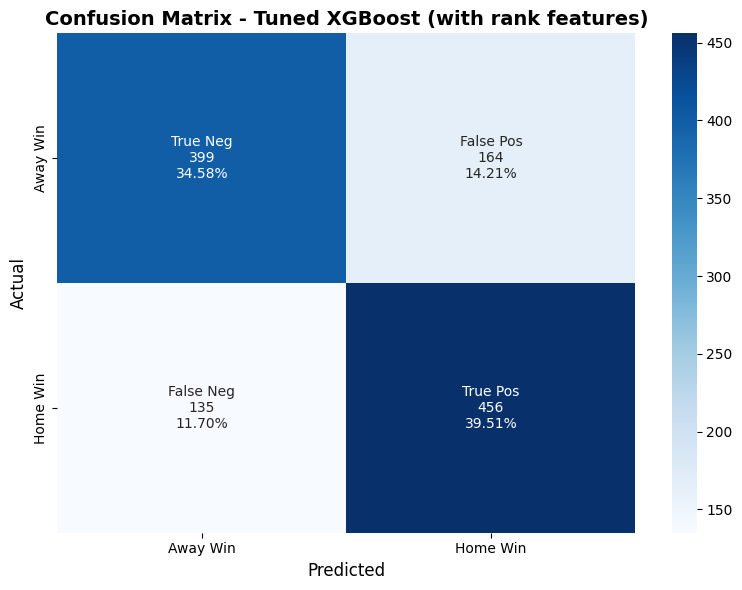


📊 Metrics:
   Accuracy:  0.7409
   Precision: 0.7355
   Recall:    0.7716
   F1 Score:  0.7531

📊 Classification Report:
              precision    recall  f1-score   support

    Away Win       0.75      0.71      0.73       563
    Home Win       0.74      0.77      0.75       591

    accuracy                           0.74      1154
   macro avg       0.74      0.74      0.74      1154
weighted avg       0.74      0.74      0.74      1154


FEATURE IMPORTANCE - TOP 15

Top 15 most important features:
               feature  importance
   avg_point_diff_diff    0.135010
         win_rate_diff    0.134955
        team_rank_diff    0.117761
       bonus_rate_diff    0.038617
avg_points_scored_diff    0.029351
         home_class_SR    0.029326
 matches_wrestled_diff    0.028671
       home_class_RSJR    0.028537
         away_class_SR    0.027435
       away_class_RSFR    0.025897
       home_class_RSSR    0.024502
       away_class_RSSR    0.023939
         away_class_SO    0.022742

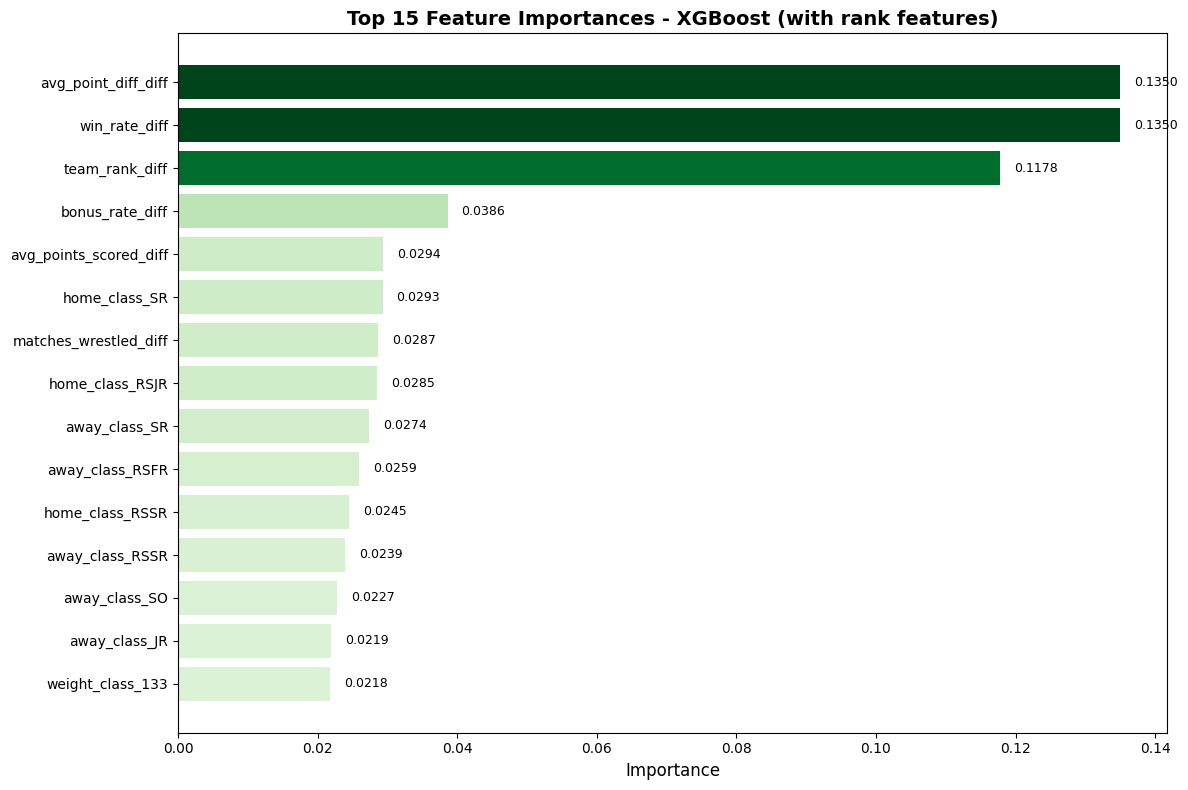


MODEL COMPARISON
          Model Train Accuracy Validation Accuracy Overfitting CV Score
Initial XGBoost         0.9849              0.7409      0.2440      N/A
  Tuned XGBoost         0.8078              0.7409      0.0668   0.7625

SAVING MODEL AND RESULTS
✅ Saved tuned XGBoost to xgb_with_ranks_tuned_OFFICIAL.pkl

✅ XGBOOST TUNING COMPLETE
Best Validation Accuracy: 0.7409
Best Parameters: {'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 10, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.15, 'gamma': 0.4, 'colsample_bytree': 0.9}


In [ ]:

# ============================================
# INITIAL MODEL (for comparison)
# ============================================
print("\n" + "="*80)
print("INITIAL MODEL (DEFAULT PARAMETERS)")
print("="*80)

xgb_initial = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_initial.fit(X_train, y_train)

train_score = xgb_initial.score(X_train, y_train)
val_score = xgb_initial.score(X_val, y_val)

print(f"Train accuracy: {train_score:.4f}")
print(f"Validation accuracy: {val_score:.4f}")
print(f"Overfitting: {train_score - val_score:.4f}")

# ============================================
# HYPERPARAMETER TUNING
# ============================================
print("\n" + "="*80)
print("HYPERPARAMETER TUNING")
print("="*80)

# Parameter distribution for XGBoost
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500, 600],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10, 12],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 3, 4, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 1, 5, 10],
    'reg_lambda': [0, 0.01, 0.1, 1, 5, 10]
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=33,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Searching 100 parameter combinations...")
random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_
best_params = random_search.best_params_
best_cv_score = random_search.best_score_

print(f"\n✅ Best CV Score: {best_cv_score:.4f}")
print(f"✅ Best Parameters: {best_params}")

# ============================================
# FINAL EVALUATION
# ============================================
print("\n" + "="*80)
print("FINAL EVALUATION")
print("="*80)

# Evaluate on validation set
train_score_tuned = accuracy_score(y_train, best_xgb.predict(X_train))
val_score_tuned = accuracy_score(y_val, best_xgb.predict(X_val))

print(f"\n📊 Final Model Performance:")
print(f"   Train accuracy: {train_score_tuned:.4f}")
print(f"   Validation accuracy: {val_score_tuned:.4f}")
print(f"   CV Score: {best_cv_score:.4f}")
print(f"   Improvement over initial: {val_score_tuned - val_score:.4f}")

# ============================================
# CONFUSION MATRIX PLOT
# ============================================
print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)

y_pred = best_xgb.predict(X_val)
cm = confusion_matrix(y_val, y_pred)
tn, fp, fn, tp = cm.ravel()

# Create annotated confusion matrix
group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2, 2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
            xticklabels=['Away Win', 'Home Win'],
            yticklabels=['Away Win', 'Home Win'])
plt.title('Confusion Matrix - Tuned XGBoost (with rank features)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('xgb_with_ranks_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n📊 Metrics:")
print(f"   Accuracy:  {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1 Score:  {f1:.4f}")

# ============================================
# CLASSIFICATION REPORT
# ============================================
print(f"\n📊 Classification Report:")
print(classification_report(y_val, y_pred, target_names=['Away Win', 'Home Win']))

# ============================================
# FEATURE IMPORTANCE BAR PLOT
# ============================================
print("\n" + "="*80)
print("FEATURE IMPORTANCE - TOP 15")
print("="*80)

feature_names = X_train.columns.tolist()
importances = best_xgb.feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nTop 15 most important features:")
print(importance_df.head(15).to_string(index=False))

# Plot top 15 features
plt.figure(figsize=(12, 8))
top_15 = importance_df.head(15)
colors = plt.cm.Greens(top_15['importance'].values / top_15['importance'].max())
bars = plt.barh(range(len(top_15)), top_15['importance'].values, color=colors)
plt.yticks(range(len(top_15)), top_15['feature'].values)
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 Feature Importances - XGBoost (with rank features)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_15['importance'].values)):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('xgb_with_ranks_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# COMPARE INITIAL VS TUNED
# ============================================
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

comparison = pd.DataFrame({
    'Model': ['Initial XGBoost', 'Tuned XGBoost'],
    'Train Accuracy': [f"{train_score:.4f}", f"{train_score_tuned:.4f}"],
    'Validation Accuracy': [f"{val_score:.4f}", f"{val_score_tuned:.4f}"],
    'Overfitting': [f"{train_score - val_score:.4f}", f"{train_score_tuned - val_score_tuned:.4f}"],
    'CV Score': ['N/A', f"{best_cv_score:.4f}"]
})

print(comparison.to_string(index=False))

# ============================================
# SAVE EVERYTHING
# ============================================
print("\n" + "="*80)
print("SAVING MODEL AND RESULTS")
print("="*80)

# Save model
filename = 'xgb_with_ranks_tuned_OFFICIAL.pkl'
with open(filename, 'wb') as f:
    pickle.dump(best_xgb, f)
print(f"✅ Saved tuned XGBoost to {filename}")
print("\n" + "="*80)
print("✅ XGBOOST TUNING COMPLETE")
print("="*80)
print(f"Best Validation Accuracy: {val_score_tuned:.4f}")
print(f"Best Parameters: {best_params}")

In [ ]:
xgb_w_ranks_features = X_train.columns

with open("xgb_w_ranks_features.pkl", "wb") as f:
    pickle.dump(xgb_w_ranks_features, f)

In [ ]:
type(xgb_w_ranks_features)

pandas.core.indexes.base.Index